In [1]:
import json
import math
import os
import gc
import itertools
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import (
    DenseNet121,
    DenseNet169,
    DenseNet201
)
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

2026-05-22 04:39:35.885327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779424776.292795      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779424776.417749      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779424777.419355      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779424777.419445      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779424777.419451      23 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [3]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Augmented Sub-datasets/AISSLab-v5/"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [4]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 72
Shape: (72, 224, 224, 3)
Total images loaded: 192
Shape: (192, 224, 224, 3)
Total images loaded: 224
Shape: (224, 224, 224, 3)
Total images loaded: 176
Shape: (176, 224, 224, 3)


In [5]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [6]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# DENSENET PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X,Y,
    test_size=0.2,
    stratify=Y,
    random_state=11
)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=11,
    stratify=y_train
)

print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (424, 224, 224, 3)
y_train: (424,)
x_val: (107, 224, 224, 3)
y_val: (107,)
x_test: (133, 224, 224, 3)
y_test: (133,)


In [8]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Convert one-hot -> labels if needed
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Check original distribution
print("Original class distribution:")
print(Counter(y_train_labels))

# Flatten image data temporarily
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# Apply Oversampling
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# Restore image shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

# One-hot Encode Labels
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)

# Final Distribution
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 143, np.int64(1): 122, np.int64(3): 113, np.int64(0): 46})

Balanced class distribution:
Counter({np.int64(1): 1200, np.int64(3): 1200, np.int64(2): 1200, np.int64(0): 1200})


In [9]:
BATCH_SIZE = 32

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam

def build_model(model_name):

    inputs = Input(shape=(224,224,3))

    if model_name=="DenseNet121":
        base_model=DenseNet121(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    elif model_name=="DenseNet169":
        base_model=DenseNet169(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    elif model_name=="DenseNet201":
        base_model=DenseNet201(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    for layer in base_model.layers:
        layer.trainable=False

    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    x=BatchNormalization()(x)
    x=Dropout(0.5)(x)
    x=Dense(256,activation="relu")(x)
    x=Dropout(0.4)(x)
    outputs=Dense(4,activation="softmax")(x)
    
    # FINAL MODEL
    model=Model(inputs,outputs)

     # COMPILE
    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model,base_model

In [11]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

def get_callbacks(model_name):

    checkpoint = ModelCheckpoint(
        f"/kaggle/working/{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    earlystop = EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    return [checkpoint, earlystop, reduce_lr]

In [12]:
def train_model(model, model_name):
    history = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=20,
        callbacks=get_callbacks(model_name)
    )
    return history

In [13]:
def fine_tune_model(model, base_model, model_name):

    # Unfreeze last 30 layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Recompile
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=30,
        callbacks=get_callbacks(model_name)
    )

    return history_fine

In [14]:
def plot_history(history, model_name):

    f, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
    f.suptitle(f'{model_name} Training History',fontsize=12)
    f.subplots_adjust(top=0.85,wspace=0.3)
    epoch_list = range(1,len(history.history['accuracy'])+1)
    ax1.plot(epoch_list,history.history['accuracy'],label='Train Accuracy')
    ax1.plot(epoch_list,history.history['val_accuracy'],label='Validation Accuracy')
    ax1.grid()
    ax1.set_ylabel('Accuracy Value')
    ax1.set_xlabel('Epoch')
    ax1.set_title('Accuracy')
    ax1.legend(loc="best")
    ax2.plot(epoch_list,history.history['loss'],label='Train Loss')
    ax2.plot(epoch_list,history.history['val_loss'],label='Validation Loss')
    ax2.grid()
    ax2.set_ylabel('Loss Value')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Loss')
    ax2.legend(loc="best")
    plt.show()

I0000 00:00:1779424880.314922      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779424880.321162      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1779424898.126021      70 service.cc:152] XLA service 0x7e286408db40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779424898.126082      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779424898.126090      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779424901.615007      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/150 ━━━━━━━━━━━━━━━━━━━━ 1:14:14 30s/step - accuracy: 0.3438 - loss: 2.2553

I0000 00:00:1779424915.184947      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.2993 - loss: 2.0139
Epoch 1: val_accuracy improved from -inf to 0.32710, saving model to /kaggle/working/DenseNet121_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 104s 496ms/step - accuracy: 0.2994 - loss: 2.0127 - val_accuracy: 0.3271 - val_loss: 1.3485 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.4016 - loss: 1.5284
Epoch 2: val_accuracy improved from 0.32710 to 0.40187, saving model to /kaggle/working/DenseNet121_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 342ms/step - accuracy: 0.4017 - loss: 1.5280 - val_accuracy: 0.4019 - val_loss: 1.2508 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4617 - loss: 1.3387
Epoch 3: val_accuracy improved from 0.40187 to 0.48598, saving model to /kaggle/working/DenseNet121_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 337ms/step - accuracy: 0.4617 - loss: 1.3385 - val_accuracy: 0.4860 - val_loss: 1.1863 

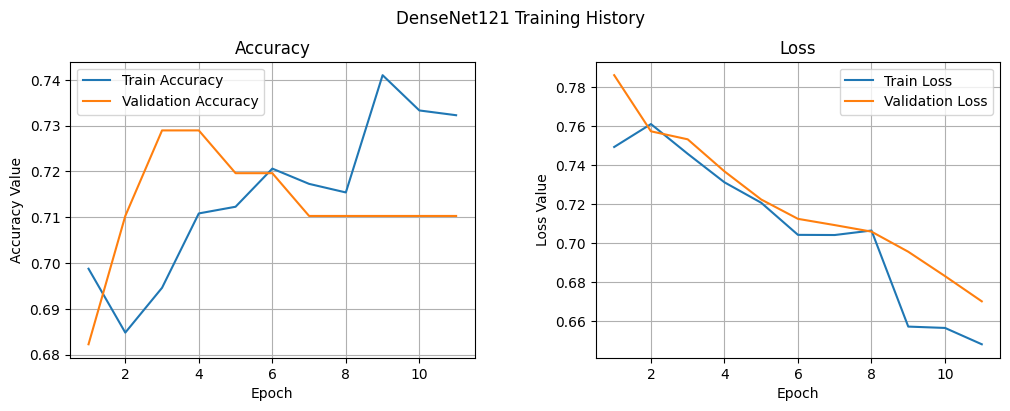

In [15]:
# BUILD MODEL
model_densenet121, base_densenet121 = build_model("DenseNet121")

# TRAIN
history_densenet121 = train_model(model_densenet121,"DenseNet121")

# FINE TUNE
history_densenet121_fine = fine_tune_model(model_densenet121,base_densenet121,"DenseNet121")

# SHOW FINAL GRAPH
plot_history(history_densenet121_fine,"DenseNet121")

In [16]:
# PREDICTION
pred_densenet121 = model_densenet121.predict(x_test)

# Predicted class
y_pred_densenet121 = np.argmax(pred_densenet121,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet121 = accuracy_score(y_true,y_pred_densenet121)
print("DenseNet121 Accuracy:",acc_densenet121)

5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step
DenseNet121 Accuracy: 0.7142857142857143


In [17]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()

gc.collect()

0

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.3094 - loss: 1.8171
Epoch 1: val_accuracy improved from -inf to 0.37383, saving model to /kaggle/working/DenseNet169_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 120s 565ms/step - accuracy: 0.3097 - loss: 1.8162 - val_accuracy: 0.3738 - val_loss: 1.2167 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.4257 - loss: 1.4570
Epoch 2: val_accuracy improved from 0.37383 to 0.43925, saving model to /kaggle/working/DenseNet169_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 356ms/step - accuracy: 0.4258 - loss: 1.4566 - val_accuracy: 0.4393 - val_loss: 1.1110 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4811 - loss: 1.2681
Epoch 3: val_accuracy improved from 0.43925 to 0.50467, saving model to /kaggle/working/DenseNet169_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 352ms/step - accuracy: 0.4812 - loss: 1.2680 - val_accuracy: 0.5047 - val_lo

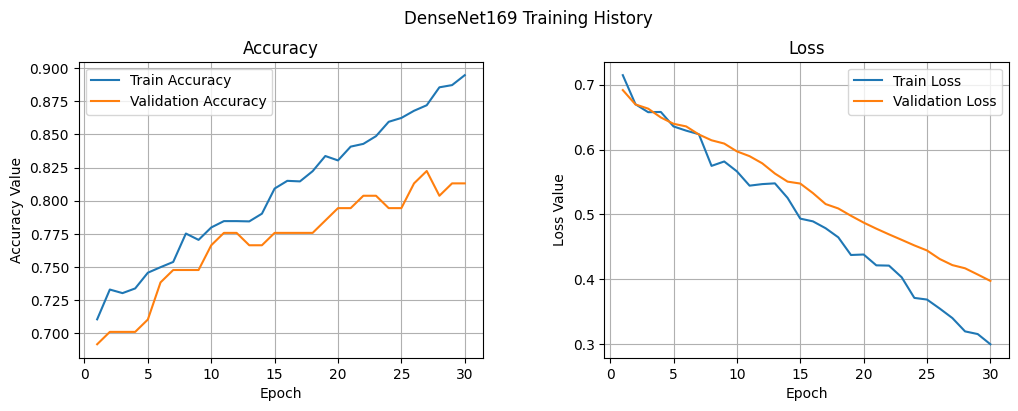

In [18]:
# BUILD MODEL
model_densenet169, base_densenet169 = build_model("DenseNet169")

# TRAIN
history_densenet169 = train_model(model_densenet169,"DenseNet169")

# FINE TUNE
history_densenet169_fine = fine_tune_model(model_densenet169,base_densenet169,"DenseNet169")

# SHOW FINAL GRAPH
plot_history(history_densenet169_fine,"DenseNet169")

In [19]:
# PREDICTION
pred_densenet169 = model_densenet169.predict(x_test)

# Predicted class
y_pred_densenet169 = np.argmax(pred_densenet169,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet169 = accuracy_score(y_true,y_pred_densenet169)

print("DenseNet169 Accuracy:",acc_densenet169)

5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step
DenseNet169 Accuracy: 0.8721804511278195


In [20]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()

gc.collect()

0

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.2865 - loss: 1.9242
Epoch 1: val_accuracy improved from -inf to 0.42056, saving model to /kaggle/working/DenseNet201_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 140s 638ms/step - accuracy: 0.2868 - loss: 1.9228 - val_accuracy: 0.4206 - val_loss: 1.2435 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.4221 - loss: 1.4219
Epoch 2: val_accuracy improved from 0.42056 to 0.46729, saving model to /kaggle/working/DenseNet201_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 368ms/step - accuracy: 0.4223 - loss: 1.4215 - val_accuracy: 0.4673 - val_loss: 1.1295 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.4886 - loss: 1.2599
Epoch 3: val_accuracy improved from 0.46729 to 0.52336, saving model to /kaggle/working/DenseNet201_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 366ms/step - accuracy: 0.4886 - loss: 1.2597 - val_accuracy: 0.5234 - val_lo

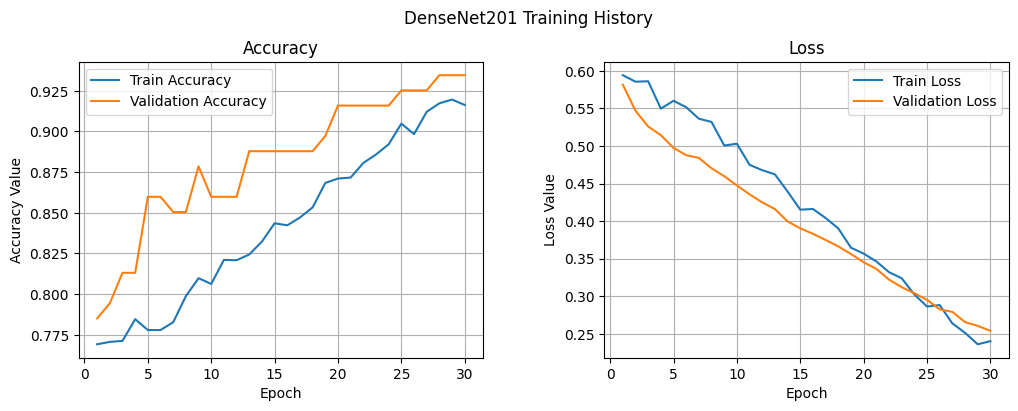

In [21]:
# BUILD MODEL
model_densenet201, base_densenet201 = build_model("DenseNet201")

# TRAIN
history_densenet201 = train_model(model_densenet201,"DenseNet201")

# FINE TUNE
history_densenet201_fine = fine_tune_model(model_densenet201,base_densenet201,"DenseNet201")

# SHOW FINAL GRAPH
plot_history(history_densenet201_fine,"DenseNet201")

In [22]:
# PREDICTION
pred_densenet201 = model_densenet201.predict(x_test)

# Predicted class
y_pred_densenet201 = np.argmax(pred_densenet201,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet201 = accuracy_score(y_true,y_pred_densenet201)

print("DenseNet201 Accuracy:",acc_densenet201)

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7e26c9c5d8a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step
DenseNet201 Accuracy: 0.9022556390977443


In [23]:
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,mean_absolute_error,mean_squared_error,cohen_kappa_score)
import itertools
def evaluate_model(model, model_name):

    print(f"\n{'='*50}")
    print(f"{model_name} EVALUATION")
    print(f"{'='*50}")

    # Prediction
    pred = model.predict(x_test)
    y_pred = np.argmax(pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred,average='weighted')
    recall = recall_score(y_true,y_pred,average='weighted')

    f1 = f1_score(y_true,y_pred,average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred )
    kappa = cohen_kappa_score(y_true,y_pred )

    # Classification Report
    print("\nClassification Report:\n")

    target_names = ['Benign (BI-RADS 2)','Benign (BI-RADS 3)','Malign (BI-RADS 4)','Malign (BI-RADS 5)']
    print(classification_report(y_true,y_pred,target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n")
    print(cm)
    # Plot CM
    plt.figure(figsize=(6,6))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks,target_names,rotation=45)
    plt.yticks(tick_marks,target_names)
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,
            format(cm[i, j], 'd'),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    # Final Metrics
    print("\nAdditional Metrics:\n")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"MCC            : {mcc:.4f}")
    print(f"Cohen Kappa    : {kappa:.4f}")
    return accuracy


DenseNet121 EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.61      1.00      0.76        14
Benign (BI-RADS 3)       0.74      0.59      0.66        39
Malign (BI-RADS 4)       0.67      0.64      0.66        45
Malign (BI-RADS 5)       0.81      0.83      0.82        35

          accuracy                           0.71       133
         macro avg       0.71      0.77      0.72       133
      weighted avg       0.72      0.71      0.71       133


Confusion Matrix:

[[14  0  0  0]
 [ 4 23  9  3]
 [ 4  8 29  4]
 [ 1  0  5 29]]


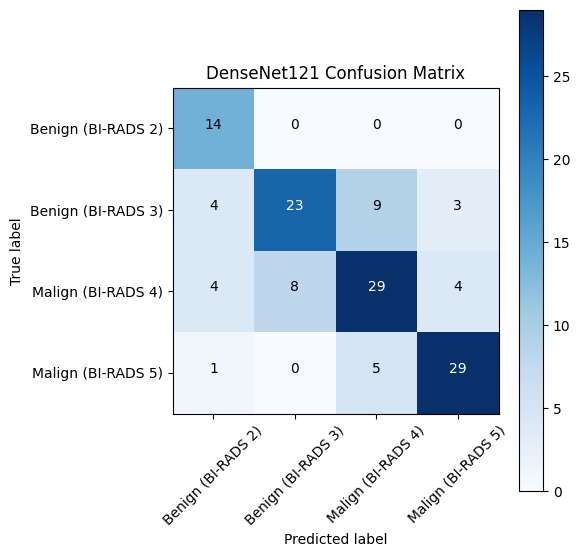


Additional Metrics:

Accuracy       : 0.7143
Precision      : 0.7218
Recall         : 0.7143
F1-score       : 0.7103
MCC            : 0.6137
Cohen Kappa    : 0.6101


In [24]:
acc_densenet121 = evaluate_model(
    model_densenet121,
    "DenseNet121"
)


DenseNet169 EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 357ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.88      1.00      0.93        14
Benign (BI-RADS 3)       0.82      0.82      0.82        39
Malign (BI-RADS 4)       0.90      0.82      0.86        45
Malign (BI-RADS 5)       0.89      0.94      0.92        35

          accuracy                           0.87       133
         macro avg       0.87      0.90      0.88       133
      weighted avg       0.87      0.87      0.87       133


Confusion Matrix:

[[14  0  0  0]
 [ 1 32  4  2]
 [ 1  5 37  2]
 [ 0  2  0 33]]


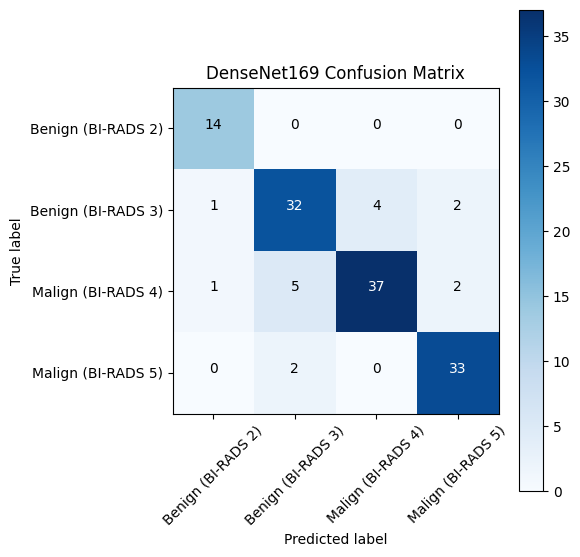


Additional Metrics:

Accuracy       : 0.8722
Precision      : 0.8728
Recall         : 0.8722
F1-score       : 0.8712
MCC            : 0.8242
Cohen Kappa    : 0.8234


In [25]:
acc_densenet169 = evaluate_model(
    model_densenet169,
    "DenseNet169"
)


DenseNet201 EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.88      1.00      0.93        14
Benign (BI-RADS 3)       0.86      0.97      0.92        39
Malign (BI-RADS 4)       1.00      0.78      0.88        45
Malign (BI-RADS 5)       0.87      0.94      0.90        35

          accuracy                           0.90       133
         macro avg       0.90      0.92      0.91       133
      weighted avg       0.91      0.90      0.90       133


Confusion Matrix:

[[14  0  0  0]
 [ 1 38  0  0]
 [ 1  4 35  5]
 [ 0  2  0 33]]


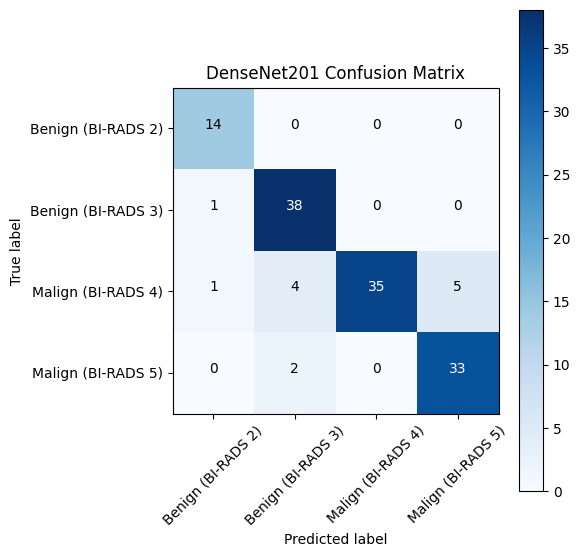


Additional Metrics:

Accuracy       : 0.9023
Precision      : 0.9122
Recall         : 0.9023
F1-score       : 0.9007
MCC            : 0.8701
Cohen Kappa    : 0.8654


In [26]:
acc_densenet201 = evaluate_model(
    model_densenet201,
    "DenseNet201"
)

In [27]:
print("\nFINAL COMPARISON")
print("="*45)

print(f"DenseNet121 Accuracy : {acc_densenet121:.4f}")
print(f"DenseNet169 Accuracy : {acc_densenet169:.4f}")
print(f"DenseNet201 Accuracy : {acc_densenet201:.4f}")

best_acc = max(acc_densenet121,acc_densenet169,acc_densenet201)

if best_acc == acc_densenet121:
    print("\nBest Model : DenseNet121")

elif best_acc == acc_densenet169:
    print("\nBest Model : DenseNet169")

else:
    print("\nBest Model : DenseNet201")


FINAL COMPARISON
DenseNet121 Accuracy : 0.7143
DenseNet169 Accuracy : 0.8722
DenseNet201 Accuracy : 0.9023

Best Model : DenseNet201
